In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch.utils.data as dataloader
import numpy as np
import torch.nn as nn

In [4]:
transformation = transforms.Compose([transforms.ToTensor()])

In [7]:
train_data = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transformation)
val_data = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transformation)

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 90.0kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.06MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.23MB/s]


In [8]:
batch_size = 256
num_classes = 10
num_channels = 1
img_size = 28
patch_size = 7
num_patches = (img_size // patch_size) ** 2
attention_heads = 10
emd_dim = 20
transformer_blocks = 8
mlp_nodes = 16
learning_rate = 0.01

In [9]:
td = dataloader.DataLoader(train_data, batch_size= batch_size, shuffle=True)
vd = dataloader.DataLoader(val_data, batch_size= batch_size, shuffle=False)

In [10]:
#Patch Embedding
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Conv2d(num_channels, emd_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.patch_embed(x).flatten(2).transpose(1,2)

In [11]:
#Transformer Encoder
class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(emd_dim)
        self.layer_norm2 = nn.LayerNorm(emd_dim)
        self.multi_head_attention = nn.MultiheadAttention(emd_dim, attention_heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(emd_dim,mlp_nodes),
            nn.GELU(),
            nn.Linear(mlp_nodes,emd_dim)
        )

    def forward(self,x):
        residual1 = x
        attention_output = self.multi_head_attention(self.layer_norm1(x),self.layer_norm1(x),self.layer_norm1(x))[0]
        x = attention_output + residual1
        residual2 = x
        mlp_output = self.mlp(self.layer_norm2(x)) 
        x = mlp_output + residual2 
        return x


In [12]:
#Vision Transformer
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embedding = PatchEmbedding()
        self.cls_token = nn.Parameter(torch.randn(1,1,emd_dim))
        self.positional_embedding = nn.Parameter(torch.randn(1,num_patches+1,emd_dim))
        self.transformer_encoder = nn.Sequential(*[TransformerEncoder() for _ in range(transformer_blocks)])
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(emd_dim),
            nn.Linear(emd_dim,10)
        )

    def forward(self,x):

        x = self.patch_embedding(x)
        Batch_size = x.size(0)
        cls_tokens = self.cls_token.expand(Batch_size,-1,-1)
        x = torch.cat((cls_tokens,x),dim=1)
        x = x + self.positional_embedding
        x = self.transformer_encoder(x)
        x = x[:,0]
        x = self.mlp_head(x)
        return x


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr= learning_rate)
criterion = nn.CrossEntropyLoss()

In [14]:
for epoch in range(5):
    model.train()
    total_loss = 0
    total_epoch = 0
    correct_epoch = 0
    print(f"\nEpoch : {epoch+1}")

    for batch_idx, (images, labels) in enumerate(td):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        prediction = outputs.argmax(dim=1)

        correct = (prediction == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

        if (batch_idx % 100 == 0):
            print(f"Batch: {batch_idx+1:3d} Loss: {loss.item():.4f} Accuracy: {accuracy:.2f}%")

epoch_accuracy = 100.0 * correct_epoch / total_epoch
print(f"Epoch {epoch+1} Summary: Total Loss: {total_loss:.4f} Accuracy: {epoch_accuracy:.2f}%")



Epoch : 1
Batch:   1 Loss: 2.3417 Accuracy: 12.50%
Batch: 101 Loss: 0.2756 Accuracy: 91.80%
Batch: 201 Loss: 0.2278 Accuracy: 92.58%

Epoch : 2
Batch:   1 Loss: 0.1387 Accuracy: 96.09%
Batch: 101 Loss: 0.0994 Accuracy: 96.48%
Batch: 201 Loss: 0.1688 Accuracy: 96.09%

Epoch : 3
Batch:   1 Loss: 0.1439 Accuracy: 94.92%
Batch: 101 Loss: 0.0660 Accuracy: 97.66%
Batch: 201 Loss: 0.1478 Accuracy: 95.70%

Epoch : 4
Batch:   1 Loss: 0.1122 Accuracy: 96.09%
Batch: 101 Loss: 0.0646 Accuracy: 98.05%
Batch: 201 Loss: 0.0628 Accuracy: 98.05%

Epoch : 5
Batch:   1 Loss: 0.1149 Accuracy: 97.66%
Batch: 101 Loss: 0.0725 Accuracy: 97.27%
Batch: 201 Loss: 0.0519 Accuracy: 99.22%
Epoch 5 Summary: Total Loss: 20.2948 Accuracy: 97.33%


In [15]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in vd:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100.0 * correct / total
print(f"\n==> Val Accuracy: {test_acc:.2f}%")



==> Val Accuracy: 96.82%


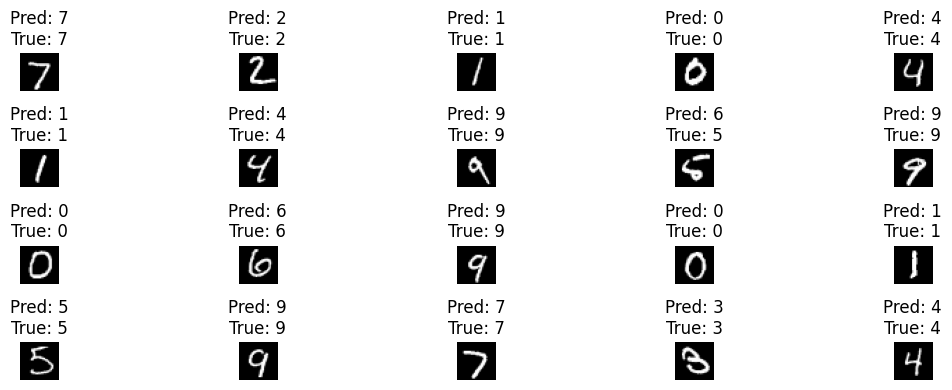

In [ ]:
model.eval()
images, labels = next(iter(vd))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)


plt.figure(figsize=(12, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


2.5.1
True
NVIDIA GeForce RTX 2050


In [1]:
import matplotlib.pyplot as plt
print("Matplotlib works 🎉")

Matplotlib works 🎉


In [ ]:
from collections import defaultdict

def per_class_accuracy(model, dataloader, device, class_names):
    model.eval()
    correct = defaultdict(int)
    total = defaultdict(int)

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for l, p in zip(labels, preds):
                total[class_names[l.item()]] += 1
                if l == p:
                    correct[class_names[l.item()]] += 1

    for cls in class_names:
        acc = correct[cls] / total[cls]
        print(f"{cls} accuracy: {acc * 100:.2f}%")
        
per_class_accuracy(model, test_loader, device, train_dataset.classes)
